# Dall'embedding lesionale allo spazio anatomico

Esplorazione (fase pre-clustering, nessun algoritmo di clustering usato) di come riportare punti/regioni
di un embedding UMAP/t-SNE (metric=Jaccard/Dice, calcolato su maschere lesionali binarie voxel-wise)
di nuovo nello spazio anatomico MNI. Tre obiettivi:

1. **Overlay singolo paziente** — maschera lesionale sul cervello MNI.
2. **Overlap/frequency map** — dato un sottoinsieme di punti (bounding box UMAP o lista di ID), quante lesioni
   coprono ciascun voxel.
3. **Densità nello spazio dell'embedding** — valutare se ha senso replicare Talozzi et al. 2023
   (coordinate UMAP -> nifti 2D + smoothing gaussiano via FSL) o se per lesioni dirette è più sensato
   lavorare esclusivamente in spazio anatomico.

Le funzioni qui sotto sono volutamente leggere/esplorative (vivono in `notebooks/`, non in `src/`,
quindi non sono soggette agli obblighi di test di `code_standards.md` §4) — riusano però la logica
già esistente e testata in `src/features/lesion.py` / `src/features/subject_discovery.py` invece di
reinventare glob/resampling/binarizzazione. Se questa direzione viene confermata, promuovere le
funzioni riutilizzabili (`resolve_lesion_paths`, `build_overlap_map`) in `src/analysis/anatomical_maps.py`
con test dedicati è il passo naturale successivo.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import seaborn as sns
from nilearn import plotting
from nilearn.image import resample_to_img

import sys
PROJECT_ROOT = Path.cwd().parents[1] if (Path.cwd().name == "post-results_analysis") else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.features.subject_discovery import discover_files_by_subject
from src.features.lesion import load_reference_image

%matplotlib inline

## Configurazione

`DATA_ROOT`/`LESION_GLOB` riflettono il **layout di retrieval attuale** (quello di
`config/pipelines/build_lesion_matrix.json` oggi in repo) — non necessariamente lo stesso config di
qualunque run storico di `build_lesion_matrix.py` si stia esplorando. Questo è deliberato, non un
taglio di rigore: durante la scrittura di questo notebook, il `config.md` del run voxel-wise usato più
sotto (`data/derived/lesion_matrix/21-07_s1.1-vol`) si è rivelato puntare a percorsi **non più esistenti**
(retrieval-layout "subject-first", migrato a "pipeline-first" in una sessione successiva — vedi
`src/features/lesion.py::_discover_lesion_files` e `docs/dev/lesion_matrix.md`). Fidarsi ciecamente del
config.md di un run avrebbe silenziosamente fallito. La soluzione adottata qui: risolvere sempre i
soggetti dal layout di retrieval **corrente**, e validare esplicitamente che ogni subject_id richiesto
sia stato trovato (mai una mappa costruita silenziosamente su un sottoinsieme più piccolo di quanto
dichiarato) — vedi `resolve_lesion_paths` più sotto.

In [2]:
BUILD_CONFIG = json.loads((PROJECT_ROOT / "config/pipelines/build_lesion_matrix.json").read_text())

DATA_ROOT = PROJECT_ROOT / BUILD_CONFIG["data_root"]
LESION_GLOB = BUILD_CONFIG["lesion_glob"]

# binarize_threshold/resample_interpolation *must* match whatever produced the
# voxel matrix feeding the embedding you're exploring - read them from that
# specific lesion-matrix run's own config.md, not assumed from the live config
# above (which may since have moved on to a different, e.g. parcellated, run).
# Both historical runs seen in this repo (21-07_s1.1-vol voxel-wise, yan300s1
# parcellated) agree on these two values, but don't assume that always holds.
BINARIZE_THRESHOLD = 0.5
RESAMPLE_INTERPOLATION = "nearest"

REFERENCE_TEMPLATE_PATH = PROJECT_ROOT / BUILD_CONFIG["reference_template_path"]
reference_img = load_reference_image(REFERENCE_TEMPLATE_PATH)
print("reference grid:", reference_img.shape, "| data_root:", DATA_ROOT, "| lesion_glob:", LESION_GLOB)

reference grid: (91, 109, 91) | data_root: /Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs/data/clinical_connectome/derivatives | lesion_glob: manual_masks/*/anat/*_label-lesion_mask.nii.gz


## 1. Overlay del singolo paziente

Nota su `reference_img` (definita sopra): è la maschera lesionale di un soggetto scelto arbitrariamente,
usata da `build_lesion_matrix` *solo* per fissare shape/affine della griglia comune — **non** è
un'immagine anatomica (T1) sensata come sfondo. Per lo sfondo anatomico si usa il template MNI152
incluso in `nilearn` (`nilearn.plotting`'s default `bg_img="MNI152"`, disponibile offline, nessun
download richiesto) — leggermente diverso come variante MNI (ICBM152 2009c nonlineare) dallo
spazio nativo dei dati (`MNI152NLin6Asym`, lineare FSL), ma la differenza è sub-millimetrica e
irrilevante per un controllo visivo qualitativo.

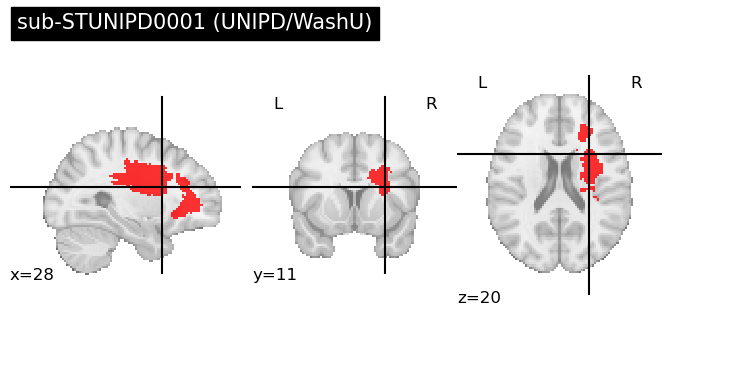

In [3]:
def find_lesion_path(dataset: str, subject_id: str) -> Path:
    """Resolve one subject's lesion mask under the current retrieval layout.

    Raises ValueError (via discover_files_by_subject / an explicit check) if
    the subject isn't found - never returns None silently, since a missing
    mask for a requested subject is a data problem the caller must see.
    """
    by_subject, _ = discover_files_by_subject(DATA_ROOT, dataset, LESION_GLOB, group_filter=None)
    if subject_id not in by_subject:
        raise ValueError(f"{subject_id!r} not found in dataset {dataset!r} under {LESION_GLOB!r}")
    return by_subject[subject_id]


def plot_subject_lesion(dataset: str, subject_id: str, save_path: Path | None = None):
    """Static ortho-view overlay (QC/figures). See also view_subject_lesion_interactive
    below for an in-notebook 3D scroll, no PNG export needed."""
    lesion_img = nib.load(find_lesion_path(dataset, subject_id))
    display = plotting.plot_roi(
        lesion_img,
        title=f"{subject_id} ({dataset})",
        cmap="autumn",
        alpha=0.8,
        display_mode="ortho",
    )
    if save_path is not None:
        display.savefig(save_path)
    return display


def view_subject_lesion_interactive(dataset: str, subject_id: str):
    """Interactive in-browser/in-notebook 3D viewer (nilearn.plotting.view_img) -
    a lighter-weight alternative to opening ITK-SNAP/MRIcroGL for a quick look;
    those desktop tools remain worth reaching for only when manually editing a
    mask or inspecting raw DICOM/T1 quality, neither of which applies here
    (masks are already computed, already in MNI space)."""
    lesion_img = nib.load(find_lesion_path(dataset, subject_id))
    return plotting.view_img(lesion_img, bg_img=None, cmap="autumn", symmetric_cmap=False, title=subject_id)


# demo
_ = plot_subject_lesion("UNIPD/WashU", "sub-STUNIPD0001")

## 2. Overlap / frequency map per un sottoinsieme di pazienti

Due funzioni riutilizzabili:
- `resolve_lesion_paths` — da una lista di `subject_id` (+ metadata per sapere il `dataset` di ciascuno)
  ai path reali dei file, con validazione esplicita (nessun soggetto mancante ignorato in silenzio).
- `build_overlap_map` — dai path risolti a due immagini NIfTI (conteggio assoluto, percentuale),
  ricampionate/binarizzate **con gli stessi identici parametri** con cui è stata costruita la matrice
  che ha alimentato l'embedding (altrimenti la overlap map non rappresenterebbe fedelmente ciò che
  UMAP/t-SNE ha effettivamente visto).

In [4]:
def resolve_lesion_paths(
    subject_ids: list[str],
    dataset_by_subject: dict[str, str],
    data_root: Path = DATA_ROOT,
    lesion_glob: str = LESION_GLOB,
) -> dict[str, Path]:
    """One discover_files_by_subject call per distinct dataset among the
    requested subjects (not one call per subject - cheap, globs once per
    dataset). Raises ValueError listing every unresolved subject_id - see the
    'Configurazione' cell above for why this must not silently degrade."""
    requested_by_dataset: dict[str, list[str]] = {}
    for subject_id in subject_ids:
        if subject_id not in dataset_by_subject:
            raise ValueError(f"{subject_id!r} has no known dataset in the supplied metadata")
        requested_by_dataset.setdefault(dataset_by_subject[subject_id], []).append(subject_id)

    resolved: dict[str, Path] = {}
    missing: list[str] = []
    for dataset, wanted in requested_by_dataset.items():
        by_subject, _ = discover_files_by_subject(data_root, dataset, lesion_glob, group_filter=None)
        for subject_id in wanted:
            if subject_id in by_subject:
                resolved[subject_id] = by_subject[subject_id]
            else:
                missing.append(subject_id)

    if missing:
        raise ValueError(
            f"{len(missing)}/{len(subject_ids)} requested subject(s) not found on disk under "
            f"{data_root} (glob={lesion_glob!r}): {sorted(missing)}"
        )
    return resolved


def build_overlap_map(
    lesion_paths: dict[str, Path],
    reference_img: nib.Nifti1Image = reference_img,
    binarize_threshold: float = BINARIZE_THRESHOLD,
    resample_interpolation: str = RESAMPLE_INTERPOLATION,
) -> tuple[nib.Nifti1Image, nib.Nifti1Image]:
    """Returns (count_img, percentage_img): count_img's voxel value is how many
    of the given subjects had a lesion there; percentage_img is that divided
    by len(lesion_paths) * 100. Same resample/binarize logic as
    src/features/lesion.py::_load_and_binarize_lesion, kept local here since
    that helper is private and 3D-flattening-specific (returns a raveled
    vector, not a volume) - if this notebook's approach is kept, unifying the
    two (e.g. a shared 3D-returning core that both _load_and_binarize_lesion
    and this call) belongs in that promotion-to-src/ step, not here."""
    if not lesion_paths:
        raise ValueError("build_overlap_map got an empty subject list - nothing to overlap")

    counts = np.zeros(reference_img.shape, dtype=np.int32)
    for path in lesion_paths.values():
        img = nib.load(path)
        if img.shape != reference_img.shape:
            img = resample_to_img(
                img, reference_img, interpolation=resample_interpolation, force_resample=True, copy_header=True
            )
        counts += (img.get_fdata() > binarize_threshold).astype(np.int32)

    percentage = (100.0 * counts / len(lesion_paths)).astype(np.float32)
    count_img = nib.Nifti1Image(counts.astype(np.int32), reference_img.affine)
    percentage_img = nib.Nifti1Image(percentage, reference_img.affine)
    return count_img, percentage_img

### Demo A — selezione esplicita per ID

Il caso più semplice: un elenco di `subject_id` già deciso (es. una coorte clinica, o punti selezionati
a mano in un plot interattivo).

/opt/anaconda3/envs/nemesis/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2625: RuntimeWarning: invalid value encountered in <lambda> (vectorized)
  outputs = ufunc(*args, out=...)


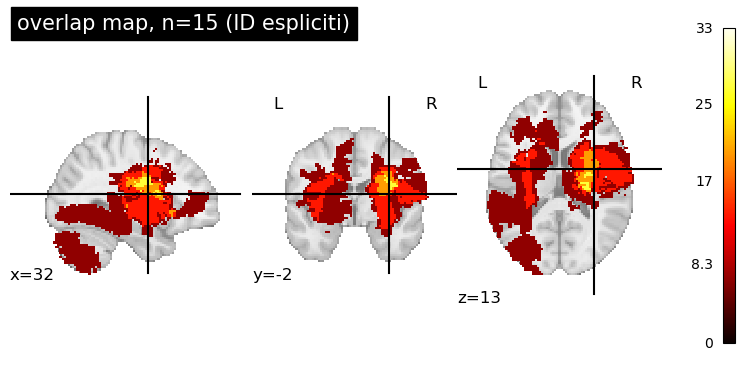

In [5]:
matrix_meta = pd.read_csv(PROJECT_ROOT / "data/derived/lesion_matrix/21-07_s1.1-vol/metadata.csv")
dataset_by_subject = dict(zip(matrix_meta["subject_id"], matrix_meta["dataset"]))

demo_ids = matrix_meta.loc[matrix_meta["dataset"] == "UNIPD/WashU", "subject_id"].head(15).tolist()
paths = resolve_lesion_paths(demo_ids, dataset_by_subject)
count_img, pct_img = build_overlap_map(paths)

display = plotting.plot_stat_map(pct_img, title=f"overlap map, n={len(paths)} (ID espliciti)", colorbar=True, cmap="hot")

### Demo B — selezione tramite bounding box sulle coordinate UMAP

Collega direttamente una regione dell'embedding già prodotto (`dim_reduction.py`, run reale
`11-08_s1.1-vol_m_dice_nc2`) alla sua controparte anatomica. `select_by_bbox` è deliberatamente la forma
più semplice (rettangolo assi-allineati su `embedding[:, 0]`/`embedding[:, 1]`); per una selezione
manuale non rettangolare in un notebook interattivo, `matplotlib.widgets.LassoSelector` (statico) o gli
eventi `selectedData` di `plotly` (`embedding_plot_interactive.html` è già `plotly`, vedi
`src/analysis/plotting.py::plot_embedding_interactive`) sono l'estensione naturale — non implementati
qui perché richiedono un frontend interattivo, non riproducibile in un'esecuzione batch di questo
notebook.

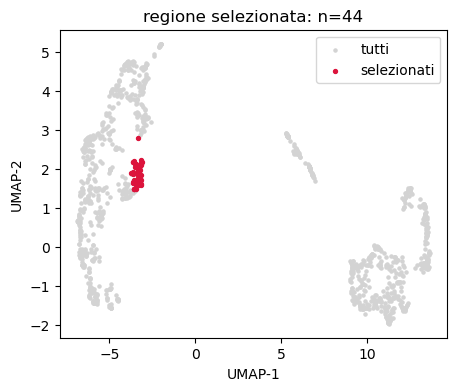

/opt/anaconda3/envs/nemesis/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2625: RuntimeWarning: invalid value encountered in <lambda> (vectorized)
  outputs = ufunc(*args, out=...)


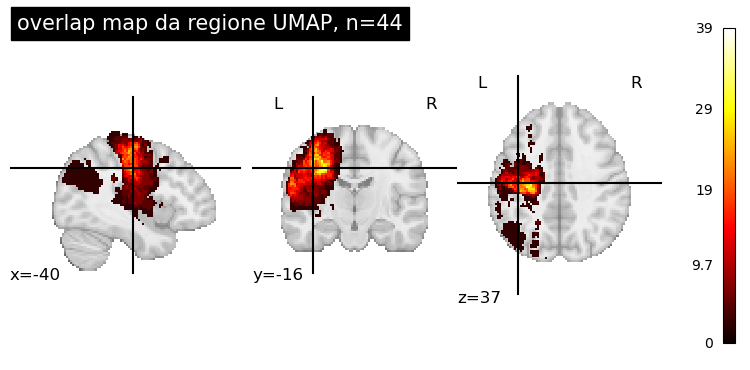

In [6]:
umap_dir = PROJECT_ROOT / "results/lesion/dim_reduction/production/umap/11-08_s1.1-vol_m_dice_nc2"
embedding = np.load(umap_dir / "matrix.npy")
umap_meta = pd.read_csv(umap_dir / "metadata.csv")


def select_by_bbox(embedding: np.ndarray, x_range: tuple[float, float], y_range: tuple[float, float]) -> np.ndarray:
    x_min, x_max = x_range
    y_min, y_max = y_range
    return (
        (embedding[:, 0] >= x_min) & (embedding[:, 0] <= x_max)
        & (embedding[:, 1] >= y_min) & (embedding[:, 1] <= y_max)
    )


# Bounding box scelta a occhio su un ammasso dell'embedding - in un notebook
# interattivo si leggerebbe direttamente da un rettangolo disegnato a mano.
x_range = tuple(np.percentile(embedding[:, 0], [40, 55]))
y_range = tuple(np.percentile(embedding[:, 1], [60, 80]))
region_mask = select_by_bbox(embedding, x_range, y_range)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(embedding[:, 0], embedding[:, 1], s=5, color="lightgray", label="tutti")
ax.scatter(embedding[region_mask, 0], embedding[region_mask, 1], s=8, color="crimson", label="selezionati")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2"); ax.legend()
ax.set_title(f"regione selezionata: n={region_mask.sum()}")
plt.show()

region_ids = umap_meta.loc[region_mask, "subject_id"].tolist()
region_datasets = dict(zip(umap_meta["subject_id"], umap_meta["dataset"]))
region_paths = resolve_lesion_paths(region_ids, region_datasets)
_, region_pct_img = build_overlap_map(region_paths)

plotting.plot_stat_map(
    region_pct_img, title=f"overlap map da regione UMAP, n={len(region_paths)}", colorbar=True, cmap="hot"
)

**Lettura del risultato**: nel run reale usato qui, la regione UMAP selezionata (44 soggetti, 4
coorti diverse) produce una overlap map anatomicamente coerente e focale (territorio fronto-parietale
sinistro, verosimile per un cluster MCA) — non un pattern rumoroso/diffuso. Questo è già di per sé una
buona validazione qualitativa di cosa l'embedding sta effettivamente catturando, indipendentemente da
qualunque clustering formale.

## 3. Densità nello spazio dell'embedding: replicare Talozzi et al. 2023?

**Cosa fa Talozzi et al. 2023** (`knowledge/nemesis/Talozzi et al - 2023.../Talozzi et al - 2023.md`,
sezione *Statistical analysis*, riga ~175): converte le coordinate UMAP in un'immagine NIfTI 2D
(260×260, pixel 0.05 mm), applica uno smoothing gaussiano (sigma 1 mm / 20 pixel) via **FSL**, ottenendo
per ogni paziente una "probabilità di localizzazione" nella morphospace. Lo scopo dichiarato non è
"visualizzare la densità" in sé, ma **modellare l'incertezza delle coordinate UMAP per poi correlarle,
pixel per pixel, con punteggi neuropsicologici** (correlazione di Pearson pixel-wise + successiva PCA
spaziale + regressione multipla) — un'immagine sintetica costruita apposta per essere l'input di
`FSL randomise` (permutation testing con correzione per confronti multipli), non un fine
visualizzativo a sé stante.

**Raccomandazione**: per l'obiettivo attuale (visualizzare *dove* si concentrano i punti nello spazio
dell'embedding, in fase pre-clustering) **non replicare la pipeline nifti+FSL** — è progettata per un
problema diverso (correlazione statistica rigorosa con outcome clinici, Task 5) e introduce una
dipendenza pesante (FSL) e un giro concettualmente contorto (impacchettare 2 coordinate reali come se
fossero un'immagine 2D) per un risultato che una KDE standard produce direttamente:

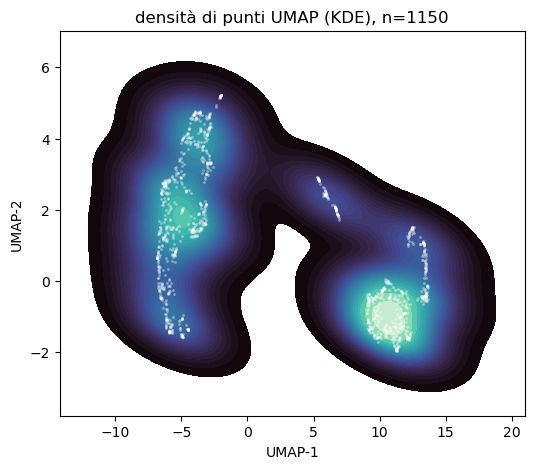

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.kdeplot(x=embedding[:, 0], y=embedding[:, 1], fill=True, cmap="mako", thresh=0.02, levels=30, ax=ax)
ax.scatter(embedding[:, 0], embedding[:, 1], s=4, color="white", alpha=0.4, linewidths=0)
ax.set_title(f"densità di punti UMAP (KDE), n={embedding.shape[0]}")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
plt.show()

`seaborn.kdeplot`/`scipy.stats.gaussian_kde` sono già nello stack (`environment.yml`), non richiedono
FSL, non richiedono di codificare coordinate 2D come voxel di un'immagine medica, e restano
interpretabili in coordinate UMAP native (nessuna conversione pixel↔coordinata da tenere a mente).
Per una selezione "a mano" di una regione ad alta densità (in vista di un futuro bounding box/lasso),
la superficie KDE stessa è già lo strumento giusto per decidere dove guardare.

**Quando *invece* avrebbe senso guardare a Talozzi**: se in futuro (Task 5) si vorrà correlare
*posizione nell'embedding* con punteggi clinici voxel(pixel)-wise con test di permutazione e correzione
per confronti multipli robusta, `FSL randomise` è un'infrastruttura statistica matura che non conviene
reimplementare da zero in puro Python — a quel punto la conversione coordinate→nifti è uno strumento
valido per *entrare* in quella infrastruttura, non uno strumento di visualizzazione.

**Lesioni dirette (voxel-wise) vs disconnectome**: per il disconnectome, Talozzi tratta la morphospace
UMAP come primo piano di analisi (i pattern di disconnessione stessi non hanno una rappresentazione
anatomica diretta comoda da confrontare 1:1 tra soggetti, l'embedding *è* lo spazio di lavoro). Per
lesioni dirette invece i dati di partenza (maschere binarie voxel-wise) **sono già** nativamente in
spazio anatomico MNI comune — l'overlap map (sezione 2) è quindi lo strumento primario e più
interpretabile per capire cosa un sottoinsieme di pazienti ha in comune; la densità nell'embedding
(questa sezione) resta un aiuto secondario per decidere *quale* regione mandare alla sezione 2, non un
sostituto.

## Riepilogo

| Obiettivo | Soluzione proposta | Dipendenze extra |
|---|---|---|
| 1. Overlay singolo paziente | `nilearn.plotting.plot_roi` / `view_img`, sfondo MNI152 di default | nessuna (già in `environment.yml`) |
| 2. Overlap map da sottoinsieme | `resolve_lesion_paths` + `build_overlap_map` (riusa `discover_files_by_subject`) | nessuna |
| 3. Densità nell'embedding | KDE (`seaborn.kdeplot`) sulle coordinate reali | nessuna — **no FSL/nifti-trick** per questo scopo |

Se questa direzione è confermata, il passo successivo naturale è promuovere `resolve_lesion_paths` /
`build_overlap_map` in un nuovo modulo `src/analysis/anatomical_maps.py` (stesso layer di
`embedding_plots.py`), con test unitari su fixture piccole (`tests/unit/test_anatomical_maps.py`) e,
se serve un uso ricorrente, un piccolo entry point CLI in `src/pipeline/` — per ora restano qui come
prototipo esplorativo, coerente con `code_standards.md`'s applicazione solo a `src/`/`scripts/`.